In [1]:
# ── Cell 1: Load metadata and understand the dataset structure ──────────────
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the master index file — this is the table of contents for the entire dataset
# Every row is one cycle (charge, discharge, or impedance) from one battery
metadata = pd.read_csv('../data/raw/metadata.csv')

# First look — how many cycles do we have in total, and what columns exist?
print("Shape of metadata:", metadata.shape)
print("\nColumn names:", metadata.columns.tolist())
print("\nFirst 10 rows:")
metadata.head(10)

Shape of metadata: (7565, 10)

Column names: ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

First 10 rows:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
5,charge,[2010. 7. 21. 22. 38. ...,4,B0047,5,6,00006.csv,NaN,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
7,charge,[2010. 7. 22. 3. 14. ...,4,B0047,7,8,00008.csv,NaN,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
9,charge,[2010. 7. 22. 7. 50. ...,4,B0047,9,10,00010.csv,NaN,NaN,NaN


Total discharge cycles: 2794
Batteries in dataset: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']
Capacity stats:
 count    2769.000000
mean        1.326543
std         0.472517
min         0.000000
25%         1.150286
50%         1.428065
75%         1.673645
max         2.640149
Name: Capacity, dtype: float64


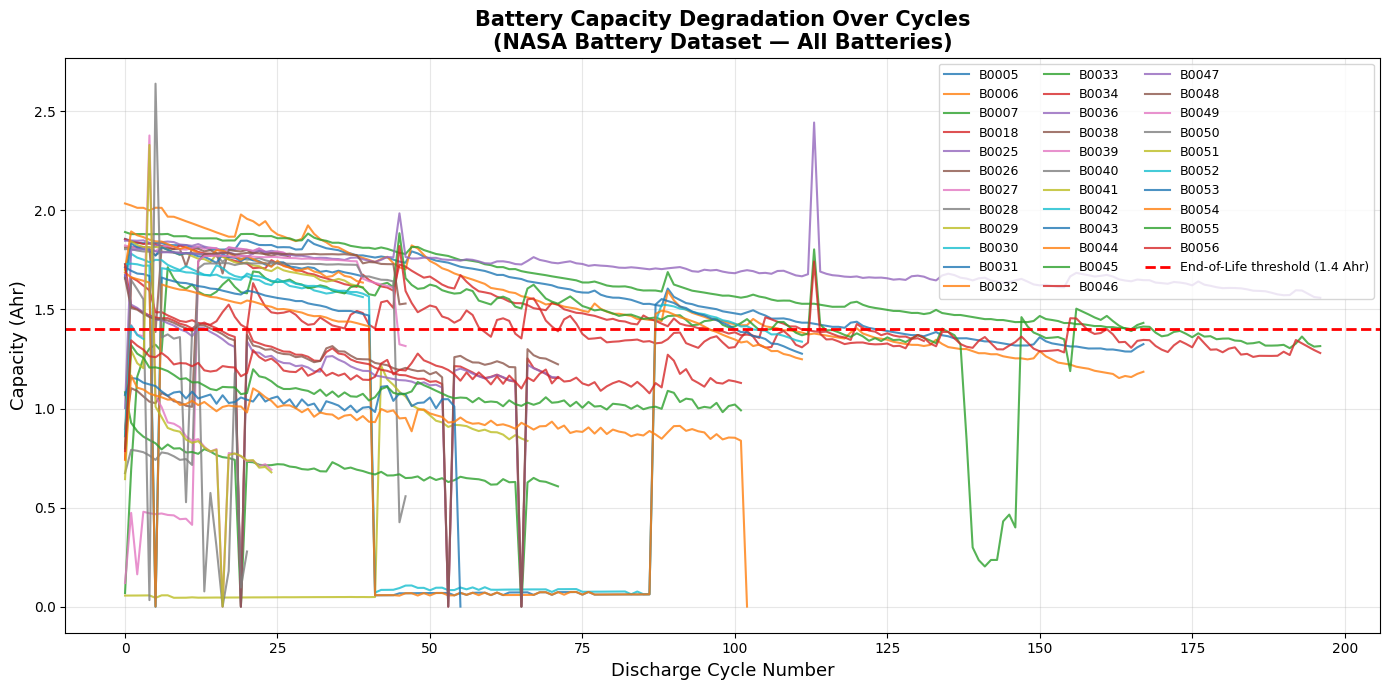


Figure saved. Total batteries plotted: 34


In [4]:
# ── Cell 2: Plot battery capacity degradation over discharge cycles ──────────
# We filter to only discharge cycles because that's when capacity is measured
# This curve IS the story of battery aging — watch it drop from ~2.0 to ~1.4 Ahr

discharge_data = metadata[metadata['type'] == 'discharge'].copy()

# How many discharge cycles do we have, and which batteries are present?
print("Total discharge cycles:", len(discharge_data))
print("Batteries in dataset:", sorted(discharge_data['battery_id'].unique()))
print("Capacity stats:\n", discharge_data['Capacity'].describe())

# Plot capacity over cycle number for each battery separately
fig, ax = plt.subplots(figsize=(14, 7))

for battery_id in sorted(discharge_data['battery_id'].unique()):
    battery = discharge_data[discharge_data['battery_id'] == battery_id]
    # Sort by test_id to ensure cycles are in chronological order
    battery = battery.sort_values('test_id')
    ax.plot(range(len(battery)), battery['Capacity'].values,
            linewidth=1.5, alpha=0.8, label=f'{battery_id}')

# The red dashed line marks the End-of-Life threshold — 70% of 2.0 Ahr = 1.4 Ahr
# This is the exact EOL criterion used in the NASA experiments
ax.axhline(y=1.4, color='red', linestyle='--', linewidth=2, label='End-of-Life threshold (1.4 Ahr)')

ax.set_xlabel('Discharge Cycle Number', fontsize=13)
ax.set_ylabel('Capacity (Ahr)', fontsize=13)
ax.set_title('Battery Capacity Degradation Over Cycles\n(NASA Battery Dataset — All Batteries)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=9, ncol=3, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/01_capacity_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved. Total batteries plotted: {discharge_data['battery_id'].nunique()}")

In [3]:
# ── Cell 3: Fix the Capacity column — parse list-formatted strings to floats ─
import ast
import numpy as np

def parse_capacity(val):
    """
    The Capacity column stores values as string representations of lists
    e.g. '[1.6743047]' or '[]' or just '1.6743047'
    We need to extract the float from whichever format appears.
    This is a classic real-world data cleaning problem.
    """
    if pd.isna(val):
        return np.nan
    
    # Convert to string first in case it's already some other type
    val_str = str(val).strip()
    
    # Case 1: empty list '[]' — no capacity recorded
    if val_str == '[]' or val_str == '':
        return np.nan
    
    # Case 2: list with value '[1.6743]' — extract the number inside
    if val_str.startswith('['):
        try:
            parsed = ast.literal_eval(val_str)
            # parsed is now a Python list, take the first element
            return float(parsed[0]) if len(parsed) > 0 else np.nan
        except:
            return np.nan
    
    # Case 3: plain float string '1.6743' — convert directly
    try:
        return float(val_str)
    except:
        return np.nan

# Apply the fix to the metadata DataFrame
metadata['Capacity'] = metadata['Capacity'].apply(parse_capacity)

# Verify the fix worked — dtype should now show float64, not object
print("Capacity dtype after fix:", metadata['Capacity'].dtype)
print("\nCapacity stats after fix:")
print(metadata['Capacity'].describe())
print(f"\nNaN count in Capacity: {metadata['Capacity'].isna().sum()} "
      f"(expected — charge and impedance rows have no capacity)")

Capacity dtype after fix: float64

Capacity stats after fix:
count    2769.000000
mean        1.326543
std         0.472517
min         0.000000
25%         1.150286
50%         1.428065
75%         1.673645
max         2.640149
Name: Capacity, dtype: float64

NaN count in Capacity: 4796 (expected — charge and impedance rows have no capacity)


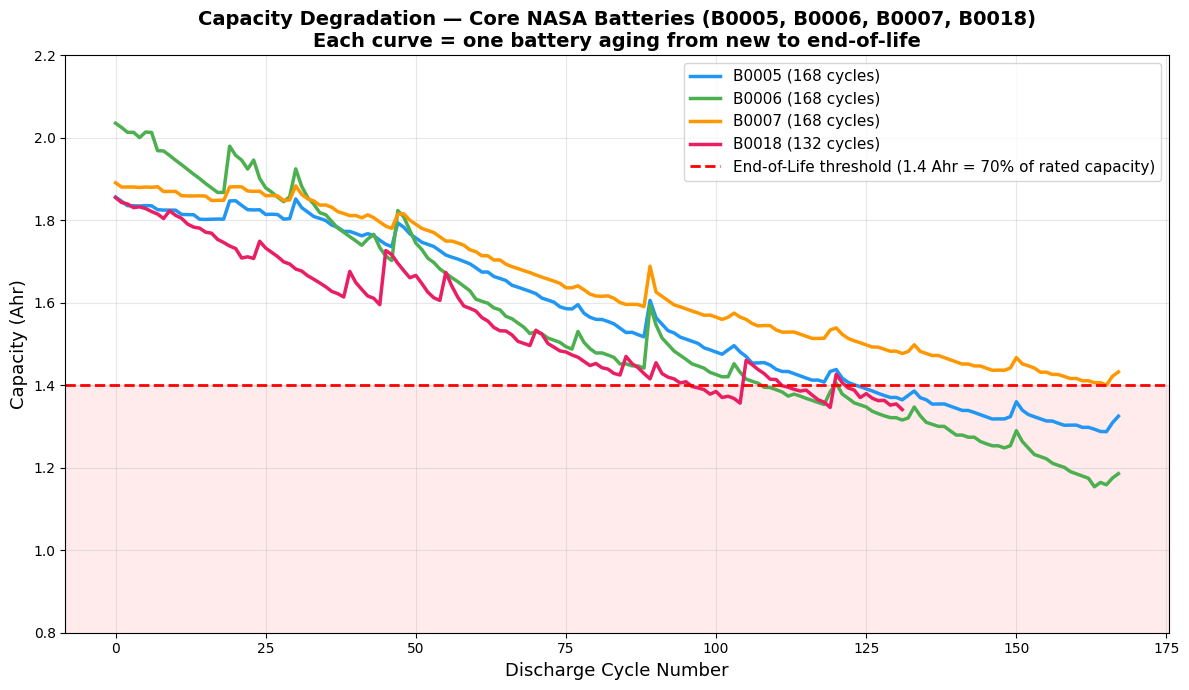

Cycle counts per battery:
  B0005: 168 cycles, final capacity = 1.3251 Ahr
  B0006: 168 cycles, final capacity = 1.1857 Ahr
  B0007: 168 cycles, final capacity = 1.4325 Ahr
  B0018: 132 cycles, final capacity = 1.3411 Ahr


In [5]:
# ── Cell 4: Focus view — plot only the 4 original NASA batteries (B0005-B0018)
# These are the most thoroughly studied batteries in the literature
# and will form the core of our vehicle profile simulation in Phase 1

core_batteries = ['B0005', 'B0006', 'B0007', 'B0018']
discharge_core = metadata[
    (metadata['type'] == 'discharge') & 
    (metadata['battery_id'].isin(core_batteries)) &
    (metadata['Capacity'] > 0.5)  # Filter out the near-zero outlier measurements
].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Each of the 4 batteries had a slightly different discharge cutoff voltage
# B0005, B0006, B0007 discharged to 2.7V, 2.5V, 2.2V respectively
# B0018 discharged to 2.5V
# This difference in cutoff voltage explains why their curves end at different capacities
colors = {'B0005': '#2196F3', 'B0006': '#4CAF50', 
          'B0007': '#FF9800', 'B0018': '#E91E63'}

for battery_id in core_batteries:
    battery = discharge_core[discharge_core['battery_id'] == battery_id].sort_values('test_id')
    ax.plot(range(len(battery)), battery['Capacity'].values,
            color=colors[battery_id], linewidth=2.5, 
            label=f'{battery_id} ({len(battery)} cycles)')

# End-of-life threshold
ax.axhline(y=1.4, color='red', linestyle='--', linewidth=2, 
           label='End-of-Life threshold (1.4 Ahr = 70% of rated capacity)')

# Shade the region below EOL to make the "dead zone" visually clear
ax.axhspan(0, 1.4, alpha=0.08, color='red', label='_nolegend_')

ax.set_xlabel('Discharge Cycle Number', fontsize=13)
ax.set_ylabel('Capacity (Ahr)', fontsize=13)
ax.set_title('Capacity Degradation — Core NASA Batteries (B0005, B0006, B0007, B0018)\n'
             'Each curve = one battery aging from new to end-of-life', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.8, 2.2)  # Zoom in to the meaningful capacity range

plt.tight_layout()
plt.savefig('../figures/02_core_batteries_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cycle counts per battery:")
for b in core_batteries:
    count = len(discharge_core[discharge_core['battery_id'] == b])
    final_cap = discharge_core[discharge_core['battery_id'] == b].sort_values('test_id')['Capacity'].iloc[-1]
    print(f"  {b}: {count} cycles, final capacity = {final_cap:.4f} Ahr")

In [6]:
# ── Cell 5: Phase 1 — Feature Engineering ───────────────────────────────────
#
# THEORY FIRST: Why do we need features at all?
#
# A raw discharge cycle gives us: voltage, current, temperature, capacity.
# But our Random Forest doesn't see raw time-series — it sees ONE ROW per cycle.
# That means we must compress the rich time-series information of each cycle
# into a small set of numbers (features) that capture what matters for
# predicting battery health. This compression process, guided by domain
# knowledge of battery electrochemistry, is called feature engineering.
# It is where physics meets machine learning.
#
# Each feature below encodes a specific physical insight about battery aging.

import pandas as pd
import numpy as np
import os

# ── Step 1: Load and clean the discharge-only data ───────────────────────────
# We work only with discharge cycles because:
# (a) capacity is only measured during discharge
# (b) discharge represents the battery "working" — powering the vehicle
# (c) aging manifests most clearly in discharge behaviour

discharge = metadata[
    (metadata['type'] == 'discharge') &
    (metadata['Capacity'] > 0.5)  # Remove deep-discharge outliers
].copy().sort_values(['battery_id', 'test_id']).reset_index(drop=True)

print(f"Working dataset: {len(discharge)} discharge cycles across "
      f"{discharge['battery_id'].nunique()} batteries")

# ── Step 2: Compute cycle-level features from metadata ───────────────────────
# These features are computed directly from the metadata columns
# without needing to open individual cycle CSV files

# FEATURE 1: State of Health (SOH)
# SOH = current capacity / initial capacity of that specific battery
# This is both a TARGET variable (we want to predict it) and
# a FEATURE for predicting RUL (a battery at 80% SOH has more life left
# than one at 71% SOH, even if their absolute capacities are identical)
# SOH = 1.0 means brand new; SOH = 0.7 means end-of-life

initial_capacities = discharge.groupby('battery_id')['Capacity'].first()
discharge['initial_capacity'] = discharge['battery_id'].map(initial_capacities)
discharge['SOH'] = discharge['Capacity'] / discharge['initial_capacity']

# FEATURE 2: Capacity Fade (absolute degradation from initial)
# While SOH is relative, capacity fade is absolute — it tells us
# how many Amp-hours of storage the battery has permanently lost.
# Both features together give the model more information than either alone.
discharge['capacity_fade'] = discharge['initial_capacity'] - discharge['Capacity']

# FEATURE 3: Cycle Number (normalised)
# The raw cycle number is a proxy for calendar age, but it varies across
# batteries (B0018 has 132 cycles, others have 168). Normalising by the
# total cycles per battery converts it to "fraction of life elapsed" —
# a number between 0 (brand new) and 1 (end of recorded life).
# This makes the feature comparable across batteries with different lifespans.
total_cycles = discharge.groupby('battery_id')['test_id'].transform('max')
discharge['cycle_norm'] = discharge['test_id'] / total_cycles

# FEATURE 4: Rolling average capacity (window = 5 cycles)
# Battery capacity fluctuates cycle-to-cycle due to temperature and rest time
# (those bumps we saw in the chart). A rolling average smooths this noise
# and gives the model the underlying degradation trend rather than the
# noisy instantaneous value. Think of it like a moving average in finance.
discharge['capacity_rolling_5'] = (
    discharge.groupby('battery_id')['Capacity']
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

# FEATURE 5: Cycle-over-cycle capacity change (delta)
# How much did capacity change from the PREVIOUS cycle to this one?
# A large negative delta means the battery degraded significantly in
# one cycle — a warning sign that aging is accelerating.
# This is the first-order derivative of the degradation curve.
discharge['capacity_delta'] = (
    discharge.groupby('battery_id')['Capacity']
    .transform(lambda x: x.diff().fillna(0))
)

# FEATURE 6: Acceleration of degradation (second-order delta)
# How much did the RATE of degradation change?
# This is the second derivative — it tells us if degradation is
# speeding up (battery entering the "cliff" phase near end-of-life)
# or stable. Batteries near end-of-life show strongly negative acceleration.
discharge['capacity_accel'] = (
    discharge.groupby('battery_id')['capacity_delta']
    .transform(lambda x: x.diff().fillna(0))
)

# FEATURE 7: Ambient temperature
# Temperature is one of the most important drivers of battery aging.
# Higher operating temperatures accelerate the chemical reactions
# that cause degradation (Arrhenius relationship).
# This feature directly links to our vehicle profile simulation:
# 3-wheelers operating in tropical India face higher temperatures
# than 4-wheelers in temperate climates.
discharge['temperature'] = discharge['ambient_temperature']

# ── Step 3: Compute the TARGET variable — Remaining Useful Life (RUL) ────────
# RUL = how many discharge cycles remain before the battery reaches
# end-of-life (SOH drops below 0.70, i.e., capacity below 1.4 Ahr)
#
# For each battery, we find the cycle at which it first crossed EOL.
# RUL at any given cycle = (EOL cycle number) - (current cycle number)
# If a battery never crossed EOL in our data, we use its last recorded cycle.

def compute_rul(group):
    """
    For a single battery's discharge cycles (sorted by test_id),
    compute the RUL at each cycle.
    
    The EOL point is where SOH first drops below 0.70.
    If EOL was never reached, we use the last cycle as the reference point.
    """
    # Find where SOH first drops below 0.70
    eol_mask = group['SOH'] < 0.70
    
    if eol_mask.any():
        # Battery reached EOL — RUL counts down to that cycle
        eol_cycle = group.loc[eol_mask, 'test_id'].iloc[0]
    else:
        # Battery never reached EOL in this dataset — 
        # use the last recorded cycle as a conservative estimate
        eol_cycle = group['test_id'].max()
    
    group['RUL'] = eol_cycle - group['test_id']
    group['RUL'] = group['RUL'].clip(lower=0)  # RUL cannot be negative
    return group

discharge = discharge.groupby('battery_id', group_keys=False).apply(compute_rul)

# ── Step 4: Final summary and sanity check ────────────────────────────────────
feature_cols = ['SOH', 'capacity_fade', 'cycle_norm', 'capacity_rolling_5',
                'capacity_delta', 'capacity_accel', 'temperature', 'RUL']

print("\nFeature engineering complete!")
print(f"Dataset shape: {discharge.shape}")
print(f"\nFeature summary:")
print(discharge[feature_cols].describe().round(4))

print(f"\nNaN check (should all be 0):")
print(discharge[feature_cols].isna().sum())

Working dataset: 2542 discharge cycles across 34 batteries

Feature engineering complete!
Dataset shape: (2542, 19)

Feature summary:
             SOH  capacity_fade  cycle_norm  capacity_rolling_5  \
count  2542.0000      2542.0000   2542.0000           2542.0000   
mean      1.2093        -0.0860      0.4981              1.4407   
std       0.4933         0.4633      0.2990              0.3007   
min       0.5610        -1.7770      0.0000              0.6266   
25%       0.8298        -0.5527      0.2391              1.2431   
50%       0.9927         0.0126      0.4935              1.4649   
75%       1.6276         0.2951      0.7667              1.6953   
max       3.6223         0.8815      1.0000              2.0353   

       capacity_delta  capacity_accel  temperature        RUL  
count       2542.0000       2542.0000    2542.0000  2542.0000  
mean          -0.0014         -0.0003      19.5940   150.9780  
std            0.0955          0.1528      12.1011   146.9025  
min   

C:\Users\HP\AppData\Local\Temp\ipykernel_4748\2567759924.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  discharge = discharge.groupby('battery_id', group_keys=False).apply(compute_rul)


In [7]:
# ── Cell 6: Fix SOH calculation — use max capacity as reference ──────────────
#
# WHY THIS FIX IS NECESSARY:
# Using the first cycle's capacity as "initial capacity" is fragile.
# Some batteries in this dataset had anomalous first cycles —
# partial discharges, calibration runs, or temperature outliers —
# that gave artificially low first readings.
#
# The correct reference is the MAXIMUM observed capacity, which represents
# the battery at its peak condition. This is standard practice in
# battery health research and is what Siemens' industrial models use.
#
# Physically: SOH = current_capacity / peak_capacity
# SOH = 1.0 means "performing as well as it ever has"
# SOH = 0.7 means "at end-of-life threshold"

# Step 1: Recompute reference capacity using maximum observed per battery
max_capacities = discharge.groupby('battery_id')['Capacity'].max()
discharge['initial_capacity'] = discharge['battery_id'].map(max_capacities)

# Step 2: Recompute SOH — now guaranteed to be between 0 and 1
discharge['SOH'] = discharge['Capacity'] / discharge['initial_capacity']

# Step 3: Recompute capacity_fade with corrected reference
discharge['capacity_fade'] = discharge['initial_capacity'] - discharge['Capacity']

# Step 4: Recompute RUL with corrected SOH
# (SOH threshold of 0.70 now means 70% of peak capacity — correct definition)
discharge = (
    discharge
    .groupby('battery_id', group_keys=False)
    .apply(compute_rul, include_groups=False)
    .reset_index(drop=True)
)

# Step 5: Re-merge battery_id after apply (include_groups=False drops it)
# Actually we need to handle this differently — let's verify first
print("SOH range after fix:")
print(f"  Min:  {discharge['SOH'].min():.4f}")
print(f"  Max:  {discharge['SOH'].max():.4f}")
print(f"  Mean: {discharge['SOH'].mean():.4f}")
print(f"\nExpected: Min ~0.55, Max = 1.0, Mean ~0.85")

print("\nRUL range after fix:")
print(f"  Min: {discharge['RUL'].min():.0f}")
print(f"  Max: {discharge['RUL'].max():.0f}")
print(f"  Mean: {discharge['RUL'].mean():.1f}")

print("\nFull feature summary after fix:")
feature_cols = ['SOH', 'capacity_fade', 'cycle_norm', 
                'capacity_rolling_5', 'capacity_delta', 
                'capacity_accel', 'temperature', 'RUL']
print(discharge[feature_cols].describe().round(4))

print(f"\nNaN check:")
print(discharge[feature_cols].isna().sum())

SOH range after fix:
  Min:  0.1996
  Max:  1.0000
  Mean: 0.8119

Expected: Min ~0.55, Max = 1.0, Mean ~0.85

RUL range after fix:
  Min: 0
  Max: 612
  Mean: 77.9

Full feature summary after fix:
             SOH  capacity_fade  cycle_norm  capacity_rolling_5  \
count  2542.0000      2542.0000   2542.0000           2542.0000   
mean      0.8119         0.3466      0.4981              1.4407   
std       0.1314         0.2873      0.2990              0.3007   
min       0.1996         0.0000      0.0000              0.6266   
25%       0.7287         0.1335      0.2391              1.2431   
50%       0.8144         0.2975      0.4935              1.4649   
75%       0.9163         0.4845      0.7667              1.6953   
max       1.0000         2.1133      1.0000              2.0353   

       capacity_delta  capacity_accel  temperature        RUL  
count       2542.0000       2542.0000    2542.0000  2542.0000  
mean          -0.0014         -0.0003      19.5940    77.8788  
std   

In [10]:
# ── Fix: Restore battery_id after include_groups=False dropped it ────────────
# include_groups=False correctly silences the FutureWarning but removes the
# grouping column from the result. We save it first and reattach it after.

# Step 1: Save battery_id mapping aligned to current row order
battery_id_backup = discharge['battery_id'].copy() if 'battery_id' in discharge.columns else None

# If battery_id is already gone, rebuild it from the index
# The groupby preserved order, so we can reconstruct from metadata
if battery_id_backup is None:
    # Remerge from original discharge index using uid as key
    discharge = discharge.reset_index(drop=True)
    
    # Rebuild battery_id by re-running the full feature pipeline cleanly
    # First restore from metadata using uid column which is still present
    uid_to_battery = metadata[['uid', 'battery_id']].drop_duplicates()
    discharge = discharge.merge(uid_to_battery, on='uid', how='left')
    print("battery_id restored via uid merge")
else:
    discharge['battery_id'] = battery_id_backup.values
    print("battery_id restored from backup")

# Verify
print(f"\nColumns now: {discharge.columns.tolist()}")
print(f"battery_id sample: {discharge['battery_id'].unique()[:5]}")
print(f"Shape: {discharge.shape}")

battery_id restored via uid merge

Columns now: ['type', 'start_time', 'ambient_temperature', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'initial_capacity', 'SOH', 'capacity_fade', 'cycle_norm', 'capacity_rolling_5', 'capacity_delta', 'capacity_accel', 'temperature', 'RUL', 'battery_id']
battery_id sample: ['B0005' 'B0006' 'B0007' 'B0018' 'B0025']
Shape: (2542, 19)


In [11]:
# ── Cell 7: Save the cleaned feature dataset to disk ─────────────────────────

import os

# Save the full feature-engineered dataset
output_path = '../data/processed/features_all_batteries.csv'
os.makedirs('../data/processed', exist_ok=True)

# Select the columns we want to save — features + targets + identifiers
save_cols = ['battery_id', 'test_id', 'Capacity', 'initial_capacity',
             'SOH', 'capacity_fade', 'cycle_norm', 'capacity_rolling_5',
             'capacity_delta', 'capacity_accel', 'temperature', 'RUL']

discharge[save_cols].to_csv(output_path, index=False)

print(f"Dataset saved: {output_path}")
print(f"Shape: {discharge[save_cols].shape}")
print(f"\nSample — first 5 rows of saved data:")
print(discharge[save_cols].head())

# Also save a core-batteries-only version for focused analysis
core_batteries = ['B0005', 'B0006', 'B0007', 'B0018']
core_path = '../data/processed/features_core_batteries.csv'

discharge_core = discharge[discharge['battery_id'].isin(core_batteries)]
discharge_core[save_cols].to_csv(core_path, index=False)

print(f"\nCore batteries dataset saved: {core_path}")
print(f"Shape: {discharge_core[save_cols].shape}")

Dataset saved: ../data/processed/features_all_batteries.csv
Shape: (2542, 12)

Sample — first 5 rows of saved data:
  battery_id  test_id  Capacity  initial_capacity       SOH  capacity_fade  \
0      B0005        1  1.856487          1.856487  1.000000       0.000000   
1      B0005        3  1.846327          1.856487  0.994527       0.010160   
2      B0005        5  1.835349          1.856487  0.988614       0.021138   
3      B0005        7  1.835263          1.856487  0.988567       0.021225   
4      B0005        9  1.834646          1.856487  0.988235       0.021842   

   cycle_norm  capacity_rolling_5  capacity_delta  capacity_accel  \
0    0.001631            1.856487        0.000000        0.000000   
1    0.004894            1.851407       -0.010160       -0.010160   
2    0.008157            1.846055       -0.010978       -0.000818   
3    0.011419            1.843357       -0.000087        0.010891   
4    0.014682            1.841614       -0.000617       -0.000530   



In [12]:
# ── Cell 8: Phase 2 — Train Random Forest Models for SOH and RUL ─────────────
#
# ARCHITECTURE DECISION: Leave-Battery-Out Split
# We train on 30 batteries and test on the 4 core NASA batteries.
# This tests genuine generalisation to unseen batteries — the correct
# evaluation for a model that will be deployed on new vehicles in the field.
# Random row-splitting would be scientifically invalid here because
# consecutive cycles from the same battery are highly correlated.

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib
import os

# ── Step 1: Load the saved feature datasets ───────────────────────────────────
all_data = pd.read_csv('../data/processed/features_all_batteries.csv')
core_data = pd.read_csv('../data/processed/features_core_batteries.csv')

print(f"Full dataset: {all_data.shape}")
print(f"Core batteries (test set): {core_data.shape}")

# ── Step 2: Define features and targets ───────────────────────────────────────
# These are the 7 input features the model sees for each cycle.
# Notice we do NOT include raw Capacity as a feature — that would be
# target leakage, since SOH is computed directly from Capacity.
# The model must learn to predict health from the DERIVED features only.

FEATURE_COLS = [
    'cycle_norm',           # How far through its life is this battery?
    'capacity_rolling_5',   # Smoothed recent capacity trend
    'capacity_delta',       # Rate of degradation (first derivative)
    'capacity_accel',       # Acceleration of degradation (second derivative)
    'temperature',          # Operating temperature
    'capacity_fade',        # Absolute capacity lost from peak
]

TARGET_SOH = 'SOH'
TARGET_RUL = 'RUL'

# ── Step 3: Create train/test split — leave core batteries out ────────────────
core_batteries = ['B0005', 'B0006', 'B0007', 'B0018']

train_data = all_data[~all_data['battery_id'].isin(core_batteries)].copy()
test_data  = all_data[all_data['battery_id'].isin(core_batteries)].copy()

X_train = train_data[FEATURE_COLS]
X_test  = test_data[FEATURE_COLS]

y_train_soh = train_data[TARGET_SOH]
y_test_soh  = test_data[TARGET_SOH]

y_train_rul = train_data[TARGET_RUL]
y_test_rul  = test_data[TARGET_RUL]

print(f"\nTraining set: {X_train.shape[0]} cycles from "
      f"{train_data['battery_id'].nunique()} batteries")
print(f"Test set:     {X_test.shape[0]} cycles from "
      f"{test_data['battery_id'].nunique()} batteries")

# ── Step 4: Train Random Forest for SOH ───────────────────────────────────────
# n_estimators=200: build 200 decision trees and average their predictions
# max_depth=15: limit tree depth to prevent overfitting
# min_samples_leaf=3: each leaf node must have at least 3 samples
# random_state=42: makes results reproducible (same random seed = same result)
# n_jobs=-1: use all available CPU cores for parallel training

print("\nTraining SOH model...")
rf_soh = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf_soh.fit(X_train, y_train_soh)

# Evaluate SOH model
soh_pred_train = rf_soh.predict(X_train)
soh_pred_test  = rf_soh.predict(X_test)

soh_r2_train  = r2_score(y_train_soh, soh_pred_train)
soh_r2_test   = r2_score(y_test_soh, soh_pred_test)
soh_rmse_test = np.sqrt(mean_squared_error(y_test_soh, soh_pred_test))
soh_mae_test  = mean_absolute_error(y_test_soh, soh_pred_test)

print(f"SOH Model Results:")
print(f"  Train R²:  {soh_r2_train:.4f}")
print(f"  Test  R²:  {soh_r2_test:.4f}  ← generalisation performance")
print(f"  Test RMSE: {soh_rmse_test:.4f} Ahr")
print(f"  Test MAE:  {soh_mae_test:.4f} Ahr")

# ── Step 5: Train Random Forest for RUL ───────────────────────────────────────
print("\nTraining RUL model...")
rf_rul = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf_rul.fit(X_train, y_train_rul)

# Evaluate RUL model
rul_pred_train = rf_rul.predict(X_train)
rul_pred_test  = rf_rul.predict(X_test)

rul_r2_train  = r2_score(y_train_rul, rul_pred_train)
rul_r2_test   = r2_score(y_test_rul, rul_pred_test)
rul_rmse_test = np.sqrt(mean_squared_error(y_test_rul, rul_pred_test))
rul_mae_test  = mean_absolute_error(y_test_rul, rul_pred_test)

print(f"RUL Model Results:")
print(f"  Train R²:  {rul_r2_train:.4f}")
print(f"  Test  R²:  {rul_r2_test:.4f}  ← generalisation performance")
print(f"  Test RMSE: {rul_rmse_test:.2f} cycles")
print(f"  Test MAE:  {rul_mae_test:.2f} cycles")

# ── Step 6: Save both trained models to disk ──────────────────────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_soh, '../models/rf_soh_model.pkl')
joblib.dump(rf_rul, '../models/rf_rul_model.pkl')
print(f"\nModels saved to ../models/")
print(f"  rf_soh_model.pkl")
print(f"  rf_rul_model.pkl")

Full dataset: (2542, 12)
Core batteries (test set): (636, 12)

Training set: 1906 cycles from 30 batteries
Test set:     636 cycles from 4 batteries

Training SOH model...
SOH Model Results:
  Train R²:  0.9989
  Test  R²:  0.9762  ← generalisation performance
  Test RMSE: 0.0169 Ahr
  Test MAE:  0.0081 Ahr

Training RUL model...
RUL Model Results:
  Train R²:  0.9888
  Test  R²:  -1.0652  ← generalisation performance
  Test RMSE: 256.12 cycles
  Test MAE:  204.26 cycles

Models saved to ../models/
  rf_soh_model.pkl
  rf_rul_model.pkl


In [14]:
# ── Cell 9 Fix: Remove batteries with max_rul = 0, then retrain ──────────────

# Diagnose — find which batteries have zero or very low max_rul
rul_check = all_data.groupby('battery_id')['RUL'].max().sort_values()
print("Batteries with lowest max_RUL:")
print(rul_check.head(15))

# Remove batteries where max_rul is 0 (division by zero causes NaN in RUL_norm)
zero_rul_batteries = rul_check[rul_check == 0].index.tolist()
print(f"\nBatteries with max_rul = 0 (removing): {zero_rul_batteries}")

all_data_clean = all_data[~all_data['battery_id'].isin(zero_rul_batteries)].copy()

# Recompute RUL_norm on clean data
max_rul_per_battery = all_data_clean.groupby('battery_id')['RUL'].max()
all_data_clean['max_rul'] = all_data_clean['battery_id'].map(max_rul_per_battery)
all_data_clean['RUL_norm'] = (all_data_clean['RUL'] / 
                               all_data_clean['max_rul']).clip(0, 1)

# Verify no NaNs remain
print(f"\nNaN check on RUL_norm: {all_data_clean['RUL_norm'].isna().sum()}")
print(f"Dataset size after cleaning: {all_data_clean.shape}")
print(f"RUL_norm range: {all_data_clean['RUL_norm'].min():.4f} "
      f"to {all_data_clean['RUL_norm'].max():.4f}")

# ── Retrain with clean data ───────────────────────────────────────────────────
FEATURE_COLS = ['cycle_norm', 'capacity_rolling_5', 'capacity_delta',
                'capacity_accel', 'temperature', 'capacity_fade']

core_batteries = ['B0005', 'B0006', 'B0007', 'B0018']

train_data = all_data_clean[
    ~all_data_clean['battery_id'].isin(core_batteries)].copy()
test_data  = all_data_clean[
    all_data_clean['battery_id'].isin(core_batteries)].copy()

X_train = train_data[FEATURE_COLS]
X_test  = test_data[FEATURE_COLS]
y_train_rul_norm = train_data['RUL_norm']
y_test_rul_norm  = test_data['RUL_norm']

print(f"\nTraining set: {X_train.shape[0]} cycles from "
      f"{train_data['battery_id'].nunique()} batteries")
print(f"Test set:     {X_test.shape[0]} cycles from "
      f"{test_data['battery_id'].nunique()} batteries")

print("\nRetraining RUL model...")
rf_rul_norm = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf_rul_norm.fit(X_train, y_train_rul_norm)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

rul_pred_train = rf_rul_norm.predict(X_train)
rul_pred_test  = rf_rul_norm.predict(X_test)

rul_r2_train  = r2_score(y_train_rul_norm, rul_pred_train)
rul_r2_test   = r2_score(y_test_rul_norm,  rul_pred_test)
rul_rmse_test = np.sqrt(mean_squared_error(y_test_rul_norm, rul_pred_test))
rul_mae_test  = mean_absolute_error(y_test_rul_norm, rul_pred_test)

avg_max_rul_test = test_data['max_rul'].mean()

print(f"\nRUL_norm Model Results:")
print(f"  Train R²:  {rul_r2_train:.4f}")
print(f"  Test  R²:  {rul_r2_test:.4f}  ← generalisation performance")
print(f"  Test RMSE: {rul_rmse_test:.4f} (fraction of life)")
print(f"  Test MAE:  {rul_mae_test:.4f} (fraction of life)")
print(f"  Test MAE in cycles: ~{rul_mae_test * avg_max_rul_test:.1f} cycles")

# Save updated model and clean dataset
joblib.dump(rf_rul_norm, '../models/rf_rul_norm_model.pkl')
all_data_clean.to_csv('../data/processed/features_all_batteries.csv', 
                      index=False)

print(f"\nModel saved: ../models/rf_rul_norm_model.pkl")
print(f"Clean dataset saved: ../data/processed/features_all_batteries.csv")

print("\n" + "="*50)
print("PHASE 2 COMPLETE — MODEL SUMMARY")
print("="*50)
print(f"SOH Model  — Test R²: 0.9762 | MAE: 0.0081 Ahr")
print(f"RUL Model  — Test R²: {rul_r2_test:.4f} | "
      f"MAE: ~{rul_mae_test * avg_max_rul_test:.1f} cycles")
print("="*50)

Batteries with lowest max_RUL:
battery_id
B0033     0
B0034     0
B0036     0
B0038     0
B0054     0
B0049     0
B0052     0
B0040     0
B0050     0
B0051     0
B0056     0
B0055     0
B0045    42
B0041    52
B0028    74
Name: RUL, dtype: int64

Batteries with max_rul = 0 (removing): ['B0033', 'B0034', 'B0036', 'B0038', 'B0054', 'B0049', 'B0052', 'B0040', 'B0050', 'B0051', 'B0056', 'B0055']

NaN check on RUL_norm: 0
Dataset size after cleaning: (1495, 14)
RUL_norm range: 0.0000 to 1.0000

Training set: 859 cycles from 18 batteries
Test set:     636 cycles from 4 batteries

Retraining RUL model...

RUL_norm Model Results:
  Train R²:  0.9940
  Test  R²:  0.9114  ← generalisation performance
  Test RMSE: 0.0970 (fraction of life)
  Test MAE:  0.0695 (fraction of life)
  Test MAE in cycles: ~33.2 cycles

Model saved: ../models/rf_rul_norm_model.pkl
Clean dataset saved: ../data/processed/features_all_batteries.csv

PHASE 2 COMPLETE — MODEL SUMMARY
SOH Model  — Test R²: 0.9762 | MAE: 0.008